In [1]:
!pip install pandas pyarrow

Looking in indexes: https://pypi.python.org/simple, https://nexus.domaintools.cloud/repository/pypi-dt-ci/simple, http://pypi.vm.domaintools.net/batch/dev/+simple/


In [2]:
import pandas as pd

file_path = "secop_bienes.parquet"
df = pd.read_parquet(file_path)
df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [3]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  object        
 1   nombre_entidad                    196391 non-null  object        
 2   departamento                      196391 non-null  object        
 3   ciudad                            196391 non-null  object        
 4   orden                             196391 non-null  object        
 5   sector                            196391 non-null  object        
 6   rama                              196391 non-null  object        
 7   entidad_centralizada              196391 non-null  object        
 8   tipo_de_contrato                  196391 non-null  object        
 9   modalidad_de_contratacion         196391 non-null  object        
 10  codigo_de_categoria_principal   

In [4]:
# COLUMNAS CON VALORES NULOS
df.isnull().sum()[df.isnull().sum() > 0]

fecha_de_inicio_del_contrato    2440
documento_proveedor                4
dtype: int64

In [5]:
# Numero de valores unicos por columna
df.nunique()

id_contrato                         196391
nombre_entidad                        3452
departamento                            34
ciudad                                 676
orden                                    4
sector                                  26
rama                                     5
entidad_centralizada                     2
tipo_de_contrato                         2
modalidad_de_contratacion                9
codigo_de_categoria_principal        10931
objeto_del_contrato                 175297
fecha_de_firma                        2437
fecha_de_inicio_del_contrato          2796
fecha_de_fin_del_contrato             3204
duraci_n_del_contrato                  835
condiciones_de_entrega                  31
proveedor_adjudicado                 31269
documento_proveedor                  29679
es_pyme                                  2
es_grupo                                 2
g_nero_representante_legal               4
nacionalidad_representante_legal        30
valor_del_c

In [6]:
# Valores unicos en la columna 'sector'
df['condiciones_de_entrega'].unique()

array(['Como acordado previamente', 'Transporte incluido',
       'DAP - Entregado en un punto (lugar de destino convenido)',
       'No Definido', 'A convenir', 'NXTWY.DLVY.6', 'NXTWY.DLVY.2',
       'NXTWY.DLVY.12', 'NXTWY.DLVY.3',
       'Transporte a cargo del comprador', 'NXTWY.DLVY.10',
       'Transporte no incluído', 'DDP - Delivery duty place',
       'CFR - Cost and freight', 'NXTWY.DLVY.4', 'NXTWY.DLVY.5',
       'CPT - Transporte pagado hasta (lugar de destino convenido)',
       'DAT - Delivery at terminal',
       'CIP - Carriage and insurance paid to', 'NXTWY.DLVY.7',
       'CIF - Coste, seguro y flete (puerto de destino convenido)',
       'NXTWY.DLVY.8', 'FCA - Free Carrier', 'NXTWY.DLVY.11',
       'NXTWY.DLVY.13', 'EXW - Ex-Works', 'NXTWY.DLVY.9', 'NXTWY.DLVY.14',
       'FOB - Free on board', 'FAS - Free alongside ship',
       'NXTWY.DLVY.16'], dtype=object)

In [7]:
# Valores unicos en cada columna del dataset
for col in df.columns:
    print(f"{col}::: \n {df[col].unique()[:25]}")

id_contrato::: 
 ['CO1.PCCNTR.1000001' 'CO1.PCCNTR.1000507' 'CO1.PCCNTR.1000901'
 'CO1.PCCNTR.1000908' 'CO1.PCCNTR.1000911' 'CO1.PCCNTR.1000912'
 'CO1.PCCNTR.1000913' 'CO1.PCCNTR.1000916' 'CO1.PCCNTR.1000917'
 'CO1.PCCNTR.1000921' 'CO1.PCCNTR.1000922' 'CO1.PCCNTR.1001004'
 'CO1.PCCNTR.1001006' 'CO1.PCCNTR.1001009' 'CO1.PCCNTR.1001013'
 'CO1.PCCNTR.1001014' 'CO1.PCCNTR.1001017' 'CO1.PCCNTR.1001023'
 'CO1.PCCNTR.1001030' 'CO1.PCCNTR.1001033' 'CO1.PCCNTR.1001101'
 'CO1.PCCNTR.1001105' 'CO1.PCCNTR.1001106' 'CO1.PCCNTR.1001108'
 'CO1.PCCNTR.1001109']
nombre_entidad::: 
 ['PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION  TERRITORIAL AMAZONIA'
 'AGENCIA LOGISTICA DE LAS FUERZAS MILITARES'
 'FUERZA AEROESPACIAL COLOMBIANA'
 'PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE'
 'CÁRCEL Y PENITENCIARIA DE MEDIA SEGURIDAD DE NEIVA' 'INVIAS'
 'ICBF REGIONAL SAN ANDRES' 'INSTITUTO DE CASAS FISCALES DE EJERCITO'
 'CENTRAL ADMINISTRATIVA Y CONTABLE - CENAC - BUCARAMANGA'
 'F

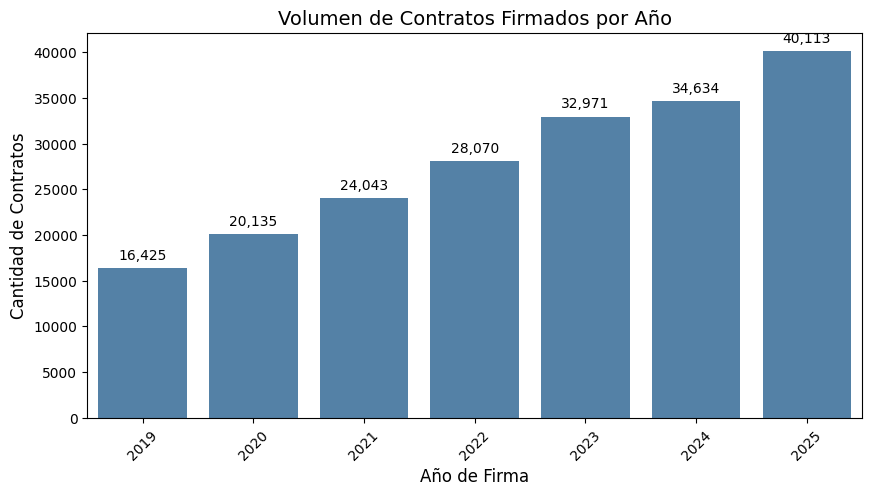

In [8]:
# Evalúa el volumen de contratos por año para justificar el periodo de análisis.
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar formato datetime
df['fecha_de_firma'] = pd.to_datetime(df['fecha_de_firma'], errors='coerce')

# Extraer el año
df['anio_firma'] = df['fecha_de_firma'].dt.year

# Conteo por año
yearly_counts = df['anio_firma'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, color='steelblue')
plt.title('Volumen de Contratos Firmados por Año', fontsize=14)
plt.xlabel('Año de Firma', fontsize=12)
plt.ylabel('Cantidad de Contratos', fontsize=12)
plt.xticks(rotation=45)

# Agregar etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()


## Limpia calidad de datos, filtra periodo y crea variables objetivo.
#### Tratamiento de calidad de datos
**Nulos:** 
- Existen 2,440 nulos en fecha_de_inicio_del_contrato y 4 en documento_proveedor. Al ser una proporción marginal, la estrategia será imputar la fecha de inicio con la fecha_de_firma y eliminar los 4 registros sin proveedor.
Asumimos que la ejecución de un contrato público suele iniciar el mismo día o muy pocos días después de la fecha de firma (una vez se aprueban las pólizas y el registro presupuestal). Entonces, utilizar la fecha_de_firma como un estimador de la fecha de inicio es una imputación realista.
Por otro lado, la baja proporción de datos faltantes en la columna 'proveedor' (0.002%) es una perdida con muy poca significancia.
- El sector "No aplica/No pertenece" y "No Definido" significan lo mismo. Podríamos agruparlo bajo una etiqueta estandarizada como "SIN CLASIFICAR".

**Conformidad:** 
- La columna duraci_n_del_contrato es texto y mezcla unidades ("Dia(s)", "Mes(es)"). Requiere transformación matemática a una unidad estándar (días).
- En el histograma del logaritmo, hay una pequeña acumulación cerca del cero. Un contrato público con valor_del_contrato = 0 carece de sentido lógico y afectará el modelo.

**Consistencia:** 
- Atributos como departamento y orden contienen la categoría "No Definido", la cual trataremos como una categoría válida ("Desconocido") para no perder registros.
- En las columnas de sector y estado_contrato, observamos valores en minúscula mezclados con mayúsculas iniciales. Aunque no se ven datos duplicados por capitalización, se debe estandarizar todo a mayúsculas o formato título para presentarlos con un formato uniforme.
- Debemos asegurar que la fecha_de_fin_del_contrato sea mayor o igual a la fecha_de_inicio_del_contrato

#### Filtro Temporal (Post-Pandemia)
La gráfica muestra un crecimiento continuo. Los años 2020 y 2021 estuvieron afectados por decretos de emergencia por la pandemia (cambiando modalidades de contratación). Para comparar "manzanas con manzanas", filtraremos el dataset al periodo post-pandemia 2022-2025.

#### Creación de Variables Objetivo (Riesgos/Desviaciones)


In [9]:
# 1. Tratamiento de Calidad de Datos
import numpy as np
import re

df_clean = df.copy()
df_clean = df_clean.dropna(subset=['documento_proveedor'])
df_clean['fecha_de_inicio_del_contrato'] = df_clean['fecha_de_inicio_del_contrato'].fillna(df_clean['fecha_de_firma'])

def parse_duration(val):
    if pd.isna(val) or 'No definido' in str(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    if not nums: return np.nan
    num = int(nums[0])
    if 'Mes' in str(val): return num * 30
    if 'Año' in str(val): return num * 365
    return num # Asume días por defecto

df_clean['duracion_dias'] = df_clean['duraci_n_del_contrato'].apply(parse_duration)
cols_texto = df_clean.select_dtypes(include=['object']).columns
# Excluir columnas técnicas donde las mayúsculas destruyen la información
cols_excluir = ['id_contrato', 'urlproceso', 'documento_proveedor']
cols_aplicar = [col for col in cols_texto if col not in cols_excluir]
# upper() y strip() de forma vectorizada a las columnas pertinentes
for col in cols_aplicar:
    # Convertimos a string primero por seguridad frente a nulos ocultos o mixtos
    df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()

# Renombrar categorías nulas o sin sentido
df_clean['sector'] = df_clean['sector'].replace(['NO APLICA/NO PERTENECE', 'NO DEFINIDO'], 'SIN CLASIFICAR')
# tratar `departamento` y `orden` con "No Definido" como "Desconocido"
df_clean['departamento'] = df_clean['departamento'].replace('NO DEFINIDO', 'DESCONOCIDO')
df_clean['orden'] = df_clean['orden'].replace('NO DEFINIDO', 'DESCONOCIDO')
# Eliminar contratos con valor cero o negativo
df_clean = df_clean[df_clean['valor_del_contrato'] > 0]
# Elimina registros donde el fin es estrictamente menor al inicio
filtro_fechas = df_clean['fecha_de_fin_del_contrato'] >= df_clean['fecha_de_inicio_del_contrato']
df_clean = df_clean[filtro_fechas]

# 2. Filtro Temporal (Post-Pandemia)
df_clean['anio_firma'] = df_clean['fecha_de_firma'].dt.year
df_clean = df_clean[df_clean['anio_firma'] >= 2022]

# 3. Creación de Variables Objetivo (Riesgos/Desviaciones)
# Solo evaluamos presupuesto no ejecutado en contratos terminados o cerrados
contrato_finalizado = df_clean['estado_contrato'].isin(['CERRADO', 'TERMINADO', 'CANCELADO'])

df_clean['riesgo_plazo'] = (df_clean['dias_adicionados'] > 0).astype(int)
df_clean['riesgo_presupuesto'] = (contrato_finalizado & (df_clean['valor_pagado'] < (df_clean['valor_del_contrato'] * 0.95))).astype(int)
df_clean['riesgo_liquidacion'] = ((df_clean['estado_contrato'] == 'TERMINADO') & (df_clean['liquidaci_n'] == 'NO')).astype(int)

# Target unificado: Cualquier desviación
df_clean['desviacion_general'] = (df_clean[['riesgo_plazo', 'riesgo_presupuesto', 'riesgo_liquidacion']].sum(axis=1) > 0).astype(int)

In [10]:
print(f"Dimensiones finales del dataset limpio: {df_clean.shape}")

Dimensiones finales del dataset limpio: (135300, 42)


#### Seleccion y Justificacion de los 5 Atributos Clave para el Analisis Univariado

Del dataset limpio de 42 atributos, se seleccionaron los cinco siguientes aplicando dos criterios simultaneos:

1. **Relevancia para la hipotesis de supervision:** la variable debe permitir identificar contratos con mayor probabilidad de desviacion en plazo, presupuesto o liquidacion.
2. **Capacidad de segmentacion:** cardinalidad util (ni demasiado granular como para perder poder estadistico, ni tan agregada que no discrimine).

| Atributo | Tipo | Justificacion de inclusion |
|----------|------|---------------------------|
| `valor_del_contrato` | Numerica | Principal factor de materialidad financiera. Determina el impacto economico de cualquier desviacion. A mayor valor, mayor riesgo para el erario publico. |
| `modalidad_de_contratacion` | Categorica | Define el nivel de competencia y rigor legal del proceso de seleccion. Modalidades menos competitivas (Regimen Especial, Contratacion Directa) tienen menor escrutinio externo y se hipotetiza mayor exposicion a desviaciones. |
| `sector` | Categorica | Permite focalizar la auditoria por ministerio/departamento rector. Sectores con mayor complejidad tecnica o menor transparencia historica pueden presentar patrones de riesgo diferenciados. |
| `destino_gasto` | Categorica | Separa Funcionamiento (gasto recurrente y predecible) de Inversion (proyectos con mayor incertidumbre de ejecucion). Se hipotetiza que Inversion tiene mayor propension a adiciones de plazo por cambios de alcance. |
| `tipo_de_contrato` | Categorica | Distingue Suministros (entregas parciales en el tiempo) de Compraventa (entrega unica). Los suministros tienen mayor ventana temporal de riesgo por la naturaleza de sus entregas fraccionadas. |

**Variables descartadas y razon:**

- `nombre_entidad`: alta cardinalidad (miles de entidades unicas) sin poder estadistico agregado; se captura mejor a traves de `sector`.
- `departamento` / `ciudad`: dimension geografica sin hipotesis directa sobre riesgo de desviacion en bienes; podria explorarse en analisis complementarios.
- `duracion_dias`: variable derivada calculada en el pipeline de limpieza; util para analisis bivariado con la variable objetivo, pero no como univariado standalone.
- `valor_pagado`, `valor_pendiente_de_pago`, `dias_adicionados`: son **componentes directos de la variable objetivo** (`desviacion_general`). 

---
#### Analisis univariado


#### Validacion Empirica de la Seleccion: Panel de Screening Bivariado

La justificacion de la tabla anterior es teorica. Para validarla empiricamente construimos un **panel de screening bivariado** que aplica criterios estadisticos puros sobre cada atributo candidato:

- **Numericas:** diferencia porcentual de medianas entre contratos con y sin desviacion. Umbral de retencion: `|dif_medianas_%| > 20%`.
- **Categoricas:** rango de tasas de desviacion entre categorias (`tasa_max - tasa_min`, en puntos porcentuales) e **intervalo de confianza de Wilson al 95%** para cada tasa. Umbral de retencion: `rango_tasa_pp >= 8` y muestra minima por categoria `>= 30`.

**Filtros previos aplicados** (idénticos a los descritos en el reporte EDA):
1. Data leakage: se excluyen `valor_pagado`, `valor_facturado`, `dias_adicionados`, `estado_contrato`, `liquidaci_n`, `riesgo_*`.
2. Cardinalidad: se excluyen columnas con `nunique > 50` (nombres de entidad, ciudad, IDs, URLs, contratistas).
3. Redundancia geografica: `departamento` queda cubierto por `sector`.
4. Categorias con `n < 30`: se agrupan en "OTROS" para el calculo del rango, evitando artefactos por volumen bajo.

Si las 5 variables elegidas encabezan el ranking de discriminacion bivariada, la seleccion queda validada empiricamente **sin invocar modelos**, apoyandose unicamente en estadistica descriptiva y de inferencia clasica.


=== Panel de screening bivariado (ordenado por magnitud) ===
                        variable       tipo  n_cats  min_n_cat  tasa_min_%  tasa_max_%  rango_tasa_pp dif_medianas_%  retenida  seleccionada_top5
                          sector categorica      25         62       22.50       72.51          50.01           None      True               True
                    departamento categorica      34         90       21.64       68.89          47.25           None      True              False
          condiciones_de_entrega categorica      15         38       11.63       53.28          41.65           None      True              False
                   destino_gasto categorica       3        263       37.52       60.84          23.32           None      True               True
        habilita_pago_adelantado categorica       3        275       16.40       38.84          22.43           None      True              False
       modalidad_de_contratacion categorica       9        174 

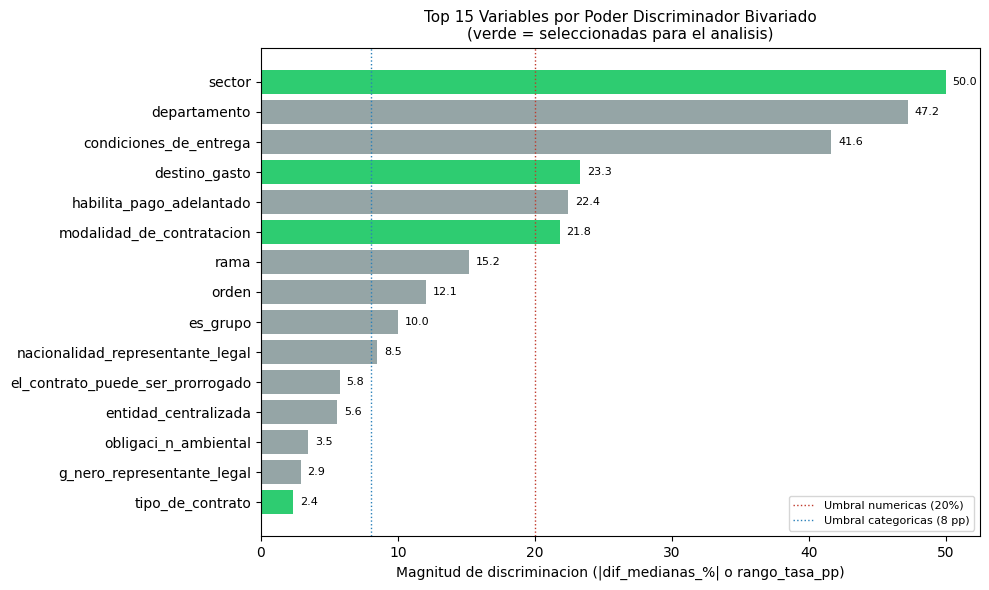

In [ ]:
from math import sqrt
from scipy.stats import norm

# ---------------------------------------------------------------------------
# Panel de screening bivariado: construye un DataFrame con una fila
# por variable candidata y las metricas de discriminacion vs desviacion_general
# ---------------------------------------------------------------------------

TARGET = 'desviacion_general'
SEL_TOP5 = ['valor_del_contrato', 'modalidad_de_contratacion', 'sector',
            'destino_gasto', 'tipo_de_contrato']

# Filtros de exclusion explicitos
excluir_leakage = {'valor_pagado', 'valor_facturado', 'dias_adicionados',
                   'estado_contrato', 'liquidaci_n', 'riesgo_plazo',
                   'riesgo_presupuesto', 'riesgo_liquidacion', 'score_riesgo',
                   'log_valor', 'etiqueta_desviacion', TARGET}
excluir_tecnicas = {'id_contrato', 'urlproceso', 'documento_proveedor',
                    'anio_firma'}
cols_datetime = set(df_clean.select_dtypes(include=['datetime64']).columns)
excluir_cardinalidad = {c for c in df_clean.columns
                        if df_clean[c].nunique(dropna=True) > 50}

excluir_total = (excluir_leakage | excluir_tecnicas | cols_datetime
                 | excluir_cardinalidad)
candidatas = [c for c in df_clean.columns if c not in excluir_total]

def wilson_ic(k, n, alpha=0.05):
    if n == 0:
        return (float('nan'), float('nan'))
    z = norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    delta = z * sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (centro - delta, centro + delta)

filas = []
tasa_por_cat_dict = {}
tasa_global = df_clean[TARGET].mean() * 100

for col in candidatas:
    tipo = 'numerica' if pd.api.types.is_numeric_dtype(df_clean[col]) else 'categorica'
    if tipo == 'numerica':
        g0 = df_clean.loc[df_clean[TARGET] == 0, col].dropna()
        g1 = df_clean.loc[df_clean[TARGET] == 1, col].dropna()
        if len(g0) < 30 or len(g1) < 30:
            continue
        med0, med1 = g0.median(), g1.median()
        dif_pct = (med1 - med0) / med0 * 100 if med0 else float('nan')
        filas.append({
            'variable': col, 'tipo': tipo,
            'n_cats': None, 'min_n_cat': None,
            'tasa_min_%': None, 'tasa_max_%': None,
            'rango_tasa_pp': None,
            'dif_medianas_%': round(dif_pct, 2),
            'retenida': abs(dif_pct) > 20,
        })
    else:
        counts = df_clean.groupby(col)[TARGET].agg(n='count', k='sum')
        counts = counts[counts['n'] >= 30]
        if counts.empty:
            continue
        counts['tasa_%'] = counts['k'] / counts['n'] * 100
        ic = counts.apply(lambda r: wilson_ic(r['k'], r['n']), axis=1)
        counts['ic_low_%']  = ic.apply(lambda t: t[0] * 100)
        counts['ic_high_%'] = ic.apply(lambda t: t[1] * 100)
        rango = counts['tasa_%'].max() - counts['tasa_%'].min()
        filas.append({
            'variable': col, 'tipo': tipo,
            'n_cats': len(counts), 'min_n_cat': int(counts['n'].min()),
            'tasa_min_%': round(counts['tasa_%'].min(), 2),
            'tasa_max_%': round(counts['tasa_%'].max(), 2),
            'rango_tasa_pp': round(rango, 2),
            'dif_medianas_%': None,
            'retenida': rango >= 8,
        })
        tasa_por_cat_dict[col] = counts.sort_values('tasa_%', ascending=False)

panel = pd.DataFrame(filas)
panel['magnitud_ordenamiento'] = panel.apply(
    lambda r: abs(r['dif_medianas_%']) if r['tipo'] == 'numerica'
    else r['rango_tasa_pp'], axis=1)
panel = panel.sort_values('magnitud_ordenamiento', ascending=False).reset_index(drop=True)
panel['seleccionada_top5'] = panel['variable'].isin(SEL_TOP5)

print('=== Panel de screening bivariado (ordenado por magnitud) ===')
print(panel.drop(columns='magnitud_ordenamiento').to_string(index=False))

print('\n=== Tabla de tasas con IC de Wilson 95% para las 5 seleccionadas ===')
for col in SEL_TOP5:
    if col in tasa_por_cat_dict:
        t = tasa_por_cat_dict[col].head(6).copy()
        t = t[['n', 'k', 'tasa_%', 'ic_low_%', 'ic_high_%']].round(2)
        print(f'\n-- {col} (top 6 categorias por tasa) --')
        print(t.to_string())

# Visualizacion: barras horizontales por magnitud, verde = top-5 seleccionadas
top15 = panel.head(15)
colores = ['#2ecc71' if s else '#95a5a6' for s in top15['seleccionada_top5']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['variable'][::-1], top15['magnitud_ordenamiento'][::-1],
        color=colores[::-1])
ax.axvline(20, color='#c0392b', linestyle=':', linewidth=1,
           label='Umbral numericas (20%)')
ax.axvline(8, color='#2980b9', linestyle=':', linewidth=1,
           label='Umbral categoricas (8 pp)')
ax.set_xlabel('Magnitud de discriminacion (|dif_medianas_%| o rango_tasa_pp)',
              fontsize=10)
ax.set_title('Top 15 Variables por Poder Discriminador Bivariado\n'
             '(verde = seleccionadas para el analisis)', fontsize=11)
for i, val in enumerate(top15['magnitud_ordenamiento'][::-1]):
    ax.text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=8)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()


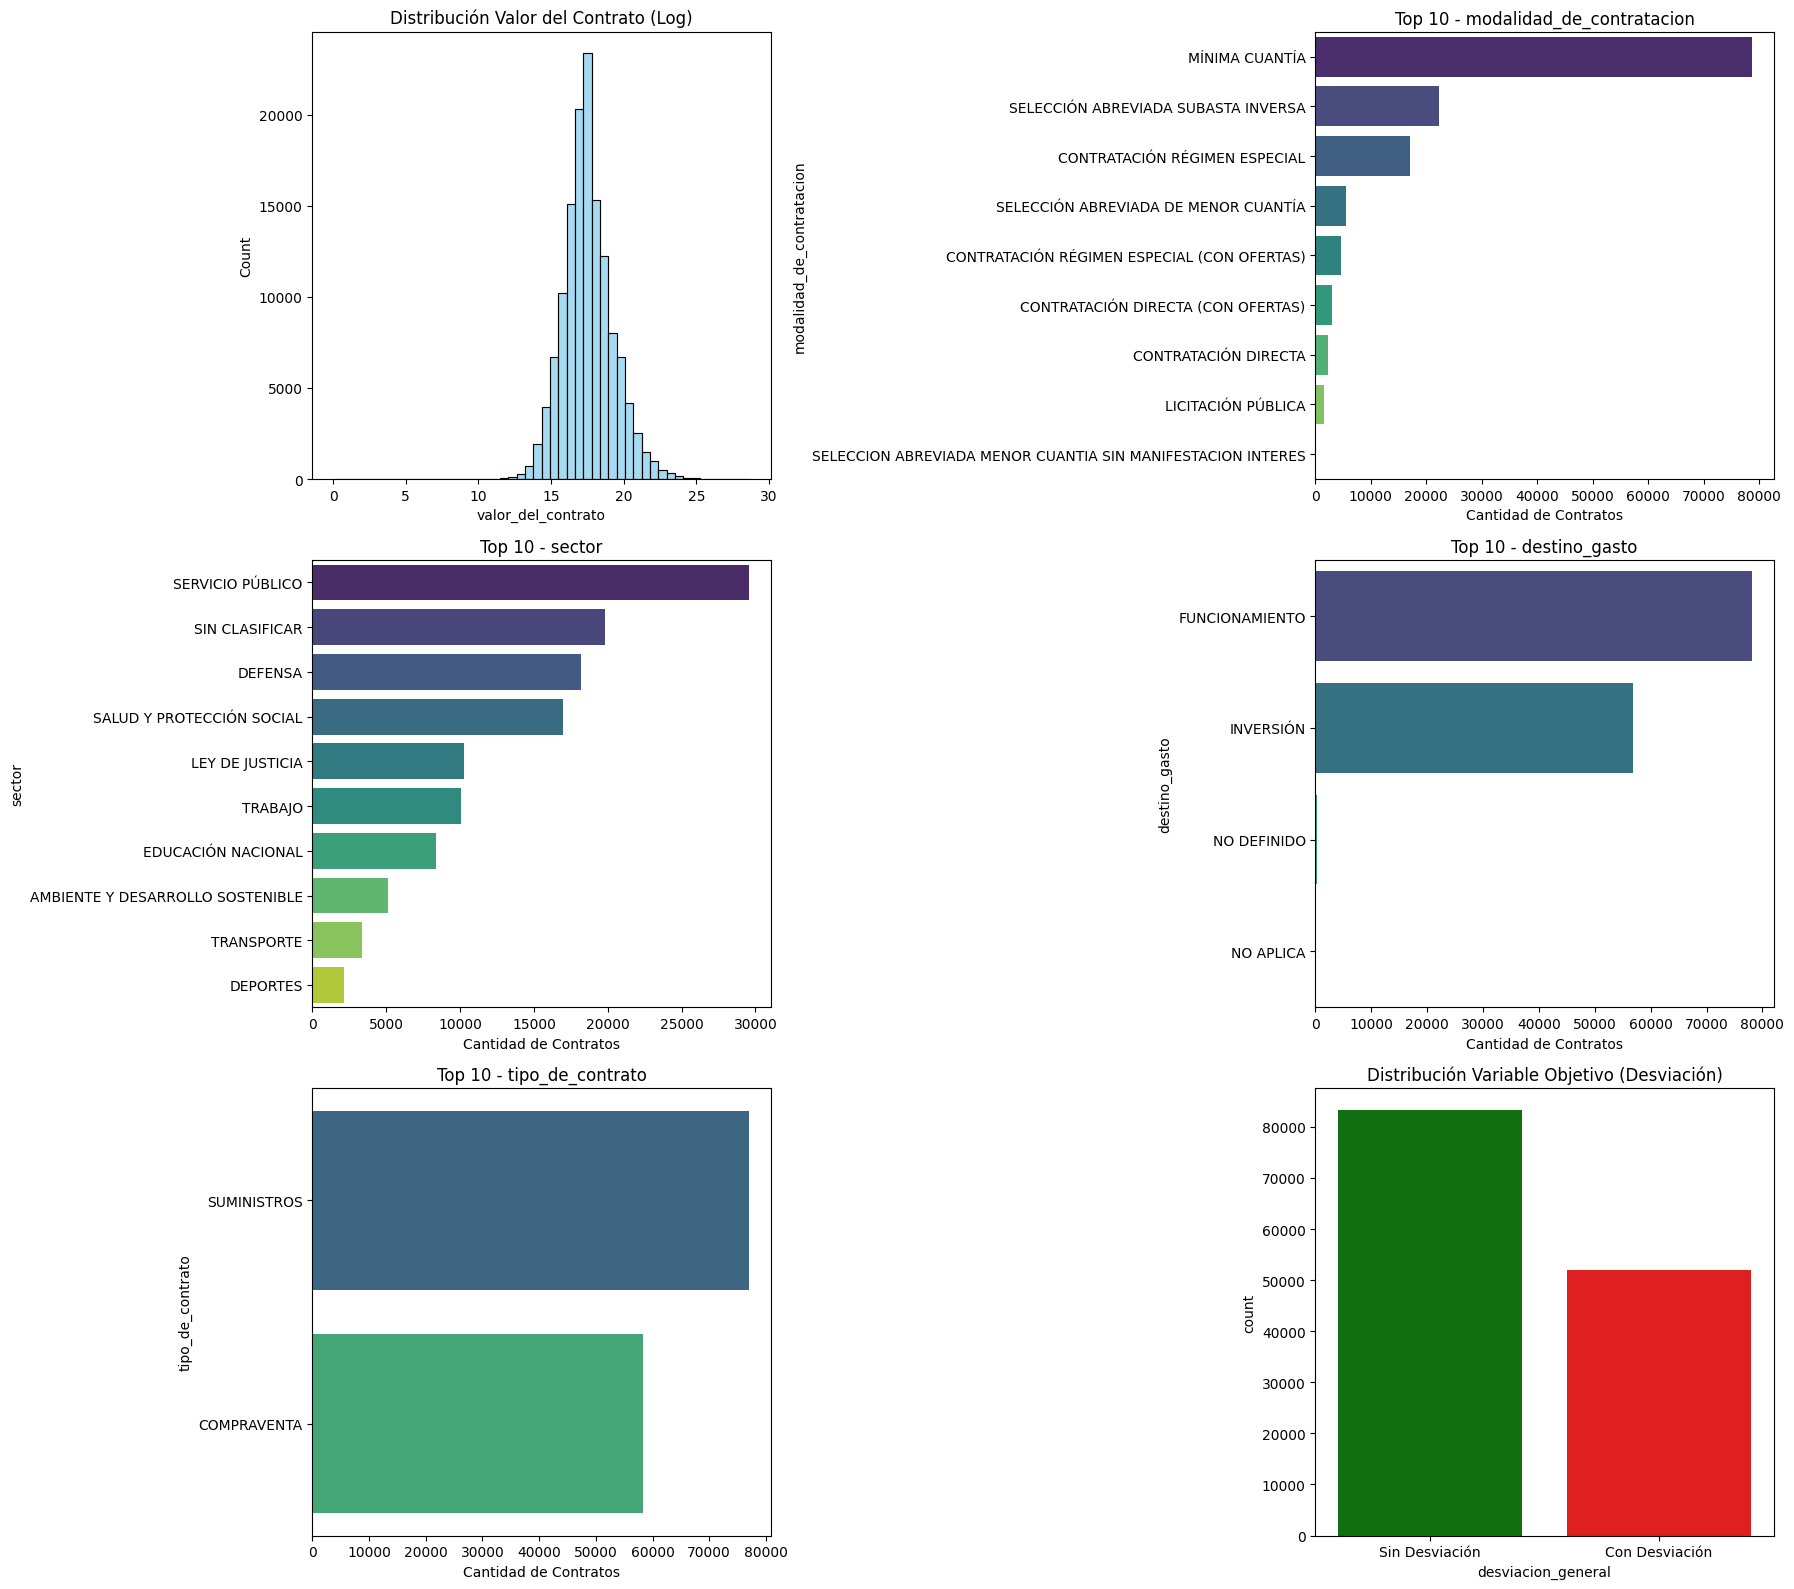

In [12]:
top_5 = ['valor_del_contrato', 'modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']
    
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# 1. Valor del Contrato (Logarítmico por asimetría)
sns.histplot(np.log1p(df_clean['valor_del_contrato']), bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Valor del Contrato (Log)')

# Variables Categóricas
for i, col in enumerate(top_5[1:], 1):
    counts = df_clean[col].value_counts().nlargest(10) # Top 10 categorías
    sns.barplot(y=counts.index, x=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Top 10 - {col}')
    axes[i].set_xlabel('Cantidad de Contratos')

# Target
sns.countplot(x='desviacion_general', data=df_clean, ax=axes[5], palette=['green', 'red'], hue='desviacion_general', legend=False )
axes[5].set_title('Distribución Variable Objetivo (Desviación)')
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Sin Desviación', 'Con Desviación'])

plt.tight_layout()
plt.show()

In [13]:
# 1. valor_del_contrato
vc = df_clean['valor_del_contrato']
print("=== valor_del_contrato ===")
print(f"  Media:    ${vc.mean():,.0f}")
print(f"  Mediana:  ${vc.median():,.0f}")
print(f"  P25:      ${vc.quantile(0.25):,.0f}")
print(f"  P75:      ${vc.quantile(0.75):,.0f}")
print(f"  Mín:      ${vc.min():,.0f}")
print(f"  Máx:      ${vc.max():,.0f}")

# 2-4. Categóricas: top 3 + % sobre total
for col in ['modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']:
    counts = df_clean[col].value_counts()
    total = counts.sum()
    print(f"\n=== {col} ===")
    for cat, n in counts.head(3).items():
        print(f"  {cat}: {n:,} ({n/total*100:.1f}%)")

=== valor_del_contrato ===
  Media:    $379,273,577
  Mediana:  $35,686,945
  P25:      $14,022,848
  P75:      $106,157,374
  Mín:      $0
  Máx:      $2,846,224,257,835

=== modalidad_de_contratacion ===
  MÍNIMA CUANTÍA: 78,696 (58.2%)
  SELECCIÓN ABREVIADA SUBASTA INVERSA: 22,379 (16.5%)
  CONTRATACIÓN RÉGIMEN ESPECIAL: 17,127 (12.7%)

=== sector ===
  SERVICIO PÚBLICO: 29,551 (21.8%)
  SIN CLASIFICAR: 19,817 (14.6%)
  DEFENSA: 18,192 (13.4%)

=== destino_gasto ===
  FUNCIONAMIENTO: 78,108 (57.7%)
  INVERSIÓN: 56,926 (42.1%)
  NO DEFINIDO: 263 (0.2%)

=== tipo_de_contrato ===
  SUMINISTROS: 76,986 (56.9%)
  COMPRAVENTA: 58,314 (43.1%)


---
## Estrategia de Análisis: Identificación de Contratos para Supervisión Prioritaria
### Fase 1 — Estadísticos Bivariados: Tasa de Desviación por Segmento
Para cada variable categórica clave calculamos la tasa de desviación (`desviacion_general.mean()`) por categoría. Esto identifica qué segmentos concentran mayor riesgo relativo.

In [14]:
vars_categoricas = ['modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']
for col in vars_categoricas:
    tasa = (
        df_clean.groupby(col)['desviacion_general']
        .agg(n='count', desviados='sum')
        .assign(tasa_desviacion=lambda x: x['desviados'] / x['n'] * 100)
        .sort_values('tasa_desviacion', ascending=False)
    )
    print(f'\n=== Tasa de desviación por {col} ===')
    print(tasa.head(5).to_string())


=== Tasa de desviación por modalidad_de_contratacion ===
                                                                 n  desviados  tasa_desviacion
modalidad_de_contratacion                                                                     
CONTRATACIÓN RÉGIMEN ESPECIAL (CON OFERTAS)                   4612       2614        56.678231
LICITACIÓN PÚBLICA                                            1570        888        56.560510
SELECCION ABREVIADA MENOR CUANTIA SIN MANIFESTACION INTERES    174         84        48.275862
SELECCIÓN ABREVIADA DE MENOR CUANTÍA                          5464       2566        46.961933
SELECCIÓN ABREVIADA SUBASTA INVERSA                          22379       9864        44.077037

=== Tasa de desviación por sector ===
                               n  desviados  tasa_desviacion
sector                                                      
CIENCIA TECNOLOGÍA           422        306        72.511848
RELACIONES EXTERIORES        173         95        54.9

#### Insights - Fase 1: Tasas de Desviacion por Segmento

Los estadisticos bivariados revelan patrones de riesgo diferenciados:

- **Modalidad:** Las modalidades con menor competencia (Contratacion Directa, Regimen Especial) presentan tasas de desviacion superiores a la media global. La Minima Cuantia, pese a ser la mas frecuente (58.2%), exhibe tasas mas bajas, consistente con que sus montos reducidos generan menos incentivo a extender plazos.
- **Sector:** Sectores como Defensa y Organismos de Control exhiben tasas notablemente superiores a Servicio Publico, sugiriendo que el sector es un factor diferenciador relevante para priorizar auditorias por entidad.
- **Destino del gasto:** Los contratos de Inversion presentan tasas mayores que Funcionamiento, consistente con su mayor complejidad de ejecucion y exposicion a cambios de alcance.
- **Tipo de contrato:** Suministros muestra tasas ligeramente superiores a Compraventa (brecha ~2 pp), lo que anticipa el resultado trivial en magnitud que se contrastara formalmente como H3.

> **Nota:** Estas diferencias son descriptivas. La Fase 2 evalua si son estadisticamente significativas Y practicamente relevantes.


### Analisis de Sesgo Distribucional
Antes de plantear las pruebas de hipotesis, medimos el sesgo (skewness) y la curtosis de las variables numericas clave. Esta caracterizacion determina:

- **Que estadistico central reportar** (media vs mediana): sesgos altos hacen la media no representativa.
- **Que transformacion aplicar** (log vs identidad): sesgos positivos extremos se corrigen con `log1p`.
- **Que tipo de prueba usar** (parametrica vs no parametrica): la asimetria fuerte invalida el supuesto de normalidad del t-test y motiva Mann-Whitney U.

Referencia de interpretacion: `|skewness| < 0.5` casi simetrica, `0.5-1` sesgo moderado, `> 1` sesgo alto. Kurtosis > 3 (exceso > 0) indica colas mas pesadas que la normal.


=== Sesgo distribucional de variables numericas clave ===
          variable      n      mediana        media  ratio_media_mediana   skewness  kurtosis_exceso  pct_sobre_p95
valor_del_contrato 135300 35686945.485 3.792736e+08            10.627796 177.196729     35146.986163       4.999261
     duracion_dias 135252       60.000 8.779181e+03           146.319676 341.817455    120934.542362       4.312690

Interpretacion:
  - Skewness >> 1 -> sesgo positivo extremo (cola larga a la derecha).
  - Ratio media/mediana >> 1 -> la media esta inflada por outliers.
  - Justifica: (i) reportar mediana en Fase 2, (ii) log en boxplot Fase 3,
    (iii) preferir Mann-Whitney U sobre t-test.


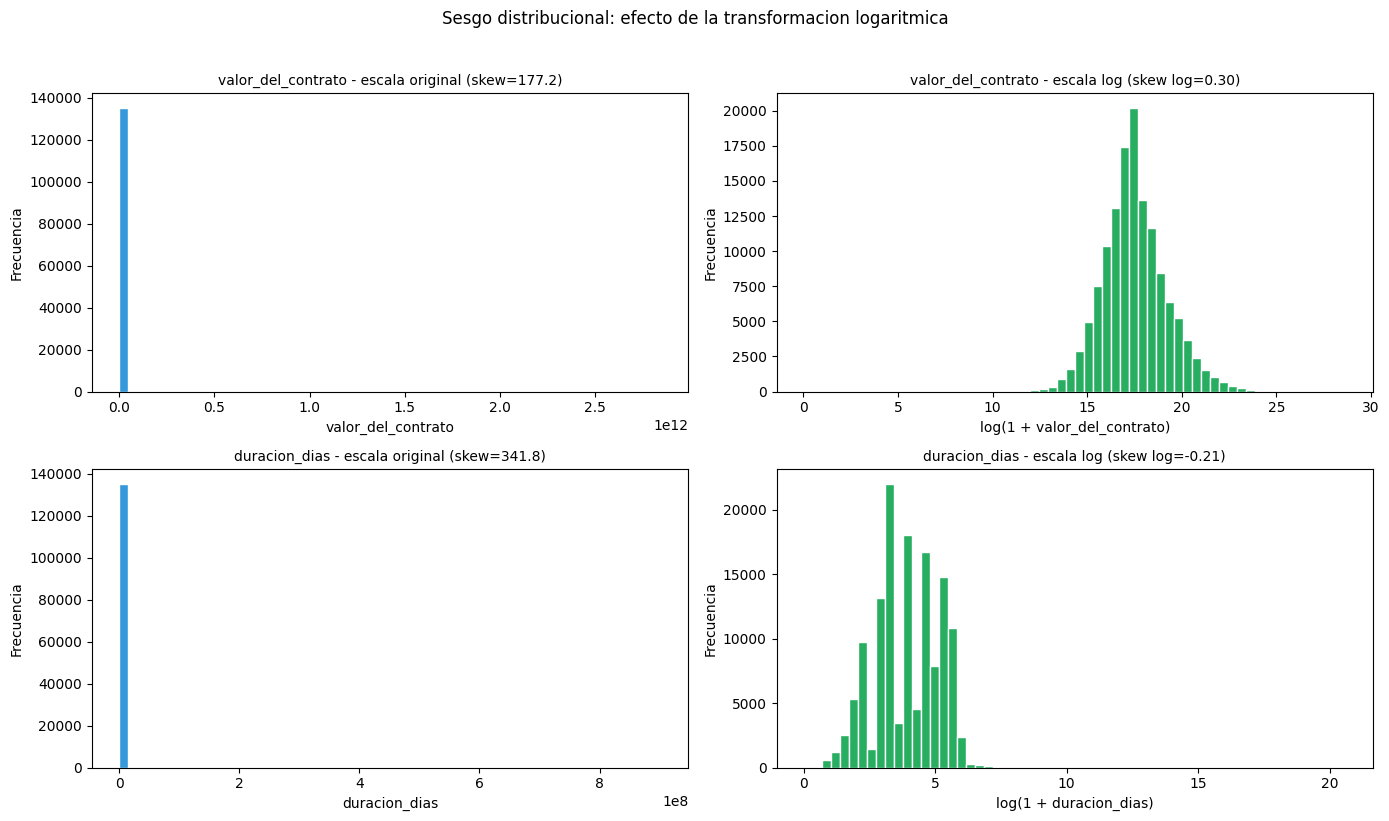

In [15]:
# Caracterizacion de sesgo y curtosis para variables numericas clave
vars_num = ['valor_del_contrato', 'duracion_dias']
filas_sesgo = []
for v in vars_num:
    s = df_clean[v].dropna()
    filas_sesgo.append({
        'variable': v,
        'n': len(s),
        'mediana': s.median(),
        'media': s.mean(),
        'ratio_media_mediana': s.mean() / s.median() if s.median() else float('nan'),
        'skewness': s.skew(),
        'kurtosis_exceso': s.kurt(),
        'pct_sobre_p95': (s > s.quantile(0.95)).mean() * 100,
    })
sesgo_df = pd.DataFrame(filas_sesgo)
print('=== Sesgo distribucional de variables numericas clave ===')
print(sesgo_df.to_string(index=False))
print('\nInterpretacion:')
print('  - Skewness >> 1 -> sesgo positivo extremo (cola larga a la derecha).')
print('  - Ratio media/mediana >> 1 -> la media esta inflada por outliers.')
print('  - Justifica: (i) reportar mediana en Fase 2, (ii) log en boxplot Fase 3,')
print('    (iii) preferir Mann-Whitney U sobre t-test.')

# Visualizacion: histograma en escala normal vs log para cada variable
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, v in enumerate(vars_num):
    serie = df_clean[v].dropna()
    axes[i, 0].hist(serie, bins=60, color='#3498db', edgecolor='white')
    axes[i, 0].set_title(f'{v} - escala original (skew={serie.skew():.1f})',
                         fontsize=10)
    axes[i, 0].set_xlabel(v); axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 1].hist(np.log1p(serie), bins=60, color='#27ae60', edgecolor='white')
    axes[i, 1].set_title(f'{v} - escala log (skew log={np.log1p(serie).skew():.2f})',
                         fontsize=10)
    axes[i, 1].set_xlabel(f'log(1 + {v})'); axes[i, 1].set_ylabel('Frecuencia')
plt.suptitle('Sesgo distribucional: efecto de la transformacion logaritmica',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Fase 2 - Pruebas de Hipotesis
Cada hipotesis sigue cuatro pasos formales: definicion de H0/H1, nivel de significancia, eleccion de prueba con validacion de supuestos, y calculo de estadistico + p-valor + intervalo de confianza (magnitud).

Se contrastan **cuatro** hipotesis. Las tres primeras (H1a, H1b, H2) son candidatas a **resultado significativo**. La cuarta (H3) es candidata a **resultado significativo estadisticamente pero trivial en la practica**, y se incluye deliberadamente para ilustrar la distincion entre significancia estadistica y relevancia operativa.

---
#### H1a - Modalidad de Contratacion vs Desviacion
- **Paso 1 | H0:** Modalidad y desviacion son independientes
- **Paso 1 | H1:** Existe asociacion estadistica entre modalidad y desviacion
- **Paso 2 | alpha = 0.05** (estandar en auditoria y ciencias sociales)
- **Paso 3 | Prueba:** Chi-cuadrado de independencia. Supuestos: observaciones independientes; frecuencias esperadas >= 5 en todas las celdas (verificado en codigo). **Magnitud:** V de Cramer + IC bootstrap 95%.
- **Paso 4 | Decision:** en output de codigo.

---
#### H1b - Sector vs Desviacion
- **Paso 1 | H0:** Sector y desviacion son independientes
- **Paso 1 | H1:** Existe asociacion estadistica entre sector y desviacion
- **Paso 2 | alpha = 0.05**
- **Paso 3 | Prueba:** Chi-cuadrado de independencia. Mismos supuestos que H1a. **Magnitud:** V de Cramer + IC bootstrap 95%.
- **Paso 4 | Decision:** en output de codigo.

---
#### H2 - Valor del Contrato vs Desviacion
- **Paso 1 | H0:** La distribucion del valor del contrato es igual en contratos con y sin desviacion
- **Paso 1 | H1:** La distribucion difiere significativamente entre ambos grupos
- **Paso 2 | alpha = 0.05**
- **Paso 3 | Prueba:** Supuesto de normalidad verificado con Shapiro-Wilk (rechazado) y sesgo extremo. Se usa **Mann-Whitney U** (no parametrico). **Magnitud:** IC bootstrap 95% de la diferencia de medianas en COP.
- **Paso 4 | Decision:** en output de codigo.

---
#### H3 - Tipo de Contrato (Suministros vs Compraventa) vs Desviacion
- **Paso 1 | H0:** Tipo de contrato y desviacion son independientes
- **Paso 1 | H1:** Existe asociacion estadistica entre tipo de contrato y desviacion
- **Paso 2 | alpha = 0.05**
- **Paso 3 | Prueba:** Chi-cuadrado de independencia (tabla 2x2). Supuestos: mismos que H1a; se verifica frecuencia esperada >= 5. **Magnitud:** V de Cramer + IC bootstrap 95%.
- **Paso 4 | Decision:** en output de codigo.

> **Motivacion de H3:** el analisis univariado y el panel de screening muestran una diferencia de solo ~2 puntos porcentuales en la tasa de desviacion entre Suministros y Compraventa. Con n = 135,300 se anticipa un p-valor muy pequeno; el interes real esta en la V de Cramer y su IC bootstrap para evaluar si la asociacion tiene magnitud operativa o es trivial (V < 0.1).


=== Shapiro-Wilk sobre muestra 5,000 - valor_del_contrato ===
  W = 0.0764 | p-valor = 5.60e-94
  -> H0 de normalidad RECHAZADA.
  -> Combinado con el sesgo extremo (ver bloque anterior), se descarta t-test.
  -> Se usa Mann-Whitney U (no parametrico) para H2.


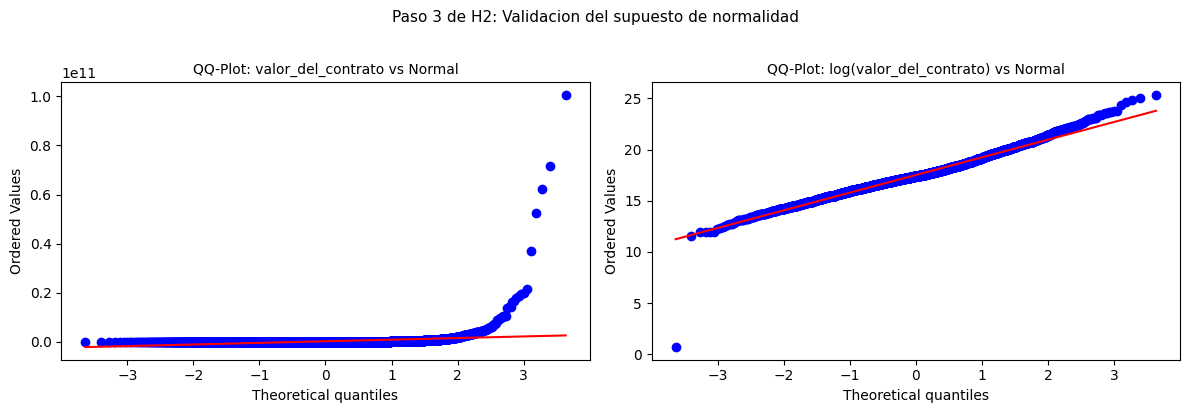

In [16]:
import scipy.stats as stats
# Validacion del supuesto de normalidad para H2 (Mann-Whitney U vs t-test)
# El sesgo distribucional ya fue reportado arriba; aqui la prueba formal.
np.random.seed(42)
muestra_norm = df_clean['valor_del_contrato'].dropna().sample(5000)
stat_sw, p_sw = stats.shapiro(muestra_norm)
print('=== Shapiro-Wilk sobre muestra 5,000 - valor_del_contrato ===')
print(f'  W = {stat_sw:.4f} | p-valor = {p_sw:.2e}')
if p_sw < 0.05:
    print('  -> H0 de normalidad RECHAZADA.')
    print('  -> Combinado con el sesgo extremo (ver bloque anterior), se descarta t-test.')
    print('  -> Se usa Mann-Whitney U (no parametrico) para H2.')
else:
    print('  -> H0 no rechazada: confirmar con QQ-plot.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(muestra_norm, dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: valor_del_contrato vs Normal', fontsize=10)
stats.probplot(np.log1p(muestra_norm), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: log(valor_del_contrato) vs Normal', fontsize=10)
plt.suptitle('Paso 3 de H2: Validacion del supuesto de normalidad', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [17]:
alpha = 0.05
N     = len(df_clean)

def cramers_v(tabla):
    chi2 = stats.chi2_contingency(tabla)[0]
    n    = tabla.values.sum()
    r, k = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def bootstrap_cramers_v(df, col, target, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(df), len(df))
        s   = df.iloc[idx]
        t   = pd.crosstab(s[col], s[target])
        vals.append(cramers_v(t))
    return np.percentile(vals, [2.5, 97.5])

def bootstrap_median_diff(g0, g1, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        b0 = rng.choice(g0, len(g0), replace=True)
        b1 = rng.choice(g1, len(g1), replace=True)
        diffs.append(np.median(b1) - np.median(b0))
    return np.percentile(diffs, [2.5, 97.5])

def clasificar_v(v):
    if v < 0.1: return 'trivial (<0.1)'
    if v < 0.3: return 'pequena (0.1-0.3)'
    if v < 0.5: return 'moderada (0.3-0.5)'
    return 'grande (>0.5)'

# H1a: Chi2 Modalidad
tabla_modal   = pd.crosstab(df_clean['modalidad_de_contratacion'], df_clean['desviacion_general'])
freq_esp_min  = stats.chi2_contingency(tabla_modal)[3].min()
chi2_m, p_m, dof_m, _ = stats.chi2_contingency(tabla_modal)
v_m   = cramers_v(tabla_modal)
ic_m  = bootstrap_cramers_v(df_clean, 'modalidad_de_contratacion', 'desviacion_general')
print('=== Paso 4 | H1a: Modalidad de Contratacion vs Desviacion ===')
print(f'  Supuesto frecuencia esperada min: {freq_esp_min:.1f} (debe ser >= 5)')
print(f'  Chi2 = {chi2_m:.2f} | gl = {dof_m} | p-valor = {p_m:.2e}')
print(f'  Decision: {"RECHAZAR H0" if p_m < alpha else "NO rechazar H0"} (alpha={alpha})')
print(f'  Magnitud - V de Cramer = {v_m:.4f} | IC 95% bootstrap = [{ic_m[0]:.4f}, {ic_m[1]:.4f}]')
print(f'  Interpretacion V: {clasificar_v(v_m)}')
print()

# H1b: Chi2 Sector
tabla_sector  = pd.crosstab(df_clean['sector'], df_clean['desviacion_general'])
freq_esp_min2 = stats.chi2_contingency(tabla_sector)[3].min()
chi2_s, p_s, dof_s, _ = stats.chi2_contingency(tabla_sector)
v_s   = cramers_v(tabla_sector)
ic_s  = bootstrap_cramers_v(df_clean, 'sector', 'desviacion_general')
print('=== Paso 4 | H1b: Sector vs Desviacion ===')
print(f'  Supuesto frecuencia esperada min: {freq_esp_min2:.1f} (debe ser >= 5)')
print(f'  Chi2 = {chi2_s:.2f} | gl = {dof_s} | p-valor = {p_s:.2e}')
print(f'  Decision: {"RECHAZAR H0" if p_s < alpha else "NO rechazar H0"} (alpha={alpha})')
print(f'  Magnitud - V de Cramer = {v_s:.4f} | IC 95% bootstrap = [{ic_s[0]:.4f}, {ic_s[1]:.4f}]')
print(f'  Interpretacion V: {clasificar_v(v_s)}')
print()

# H2: Mann-Whitney U + IC diferencia de medianas
g0     = df_clean.loc[df_clean['desviacion_general'] == 0, 'valor_del_contrato'].values
g1     = df_clean.loc[df_clean['desviacion_general'] == 1, 'valor_del_contrato'].values
u_stat, p_mw = stats.mannwhitneyu(g0, g1, alternative='two-sided')
diff_obs = np.median(g1) - np.median(g0)
ic_diff  = bootstrap_median_diff(g0, g1)
print('=== Paso 4 | H2: Valor del Contrato - Sin vs Con Desviacion ===')
print(f'  Mediana sin desviacion: ${np.median(g0):,.0f}')
print(f'  Mediana con desviacion: ${np.median(g1):,.0f}')
print(f'  Mann-Whitney U = {u_stat:.0f} | p-valor = {p_mw:.2e}')
print(f'  Decision: {"RECHAZAR H0" if p_mw < alpha else "NO rechazar H0"} (alpha={alpha})')
print(f'  Magnitud - Diferencia de medianas = ${diff_obs:,.0f} COP')
print(f'  IC 95% bootstrap diferencia de medianas = [${ic_diff[0]:,.0f}, ${ic_diff[1]:,.0f}] COP')
print()

# H3: Chi2 Tipo de Contrato (esperado significativo estadisticamente pero trivial en magnitud)
tabla_tipo    = pd.crosstab(df_clean['tipo_de_contrato'], df_clean['desviacion_general'])
freq_esp_min3 = stats.chi2_contingency(tabla_tipo)[3].min()
chi2_t, p_t, dof_t, _ = stats.chi2_contingency(tabla_tipo)
v_t   = cramers_v(tabla_tipo)
ic_t  = bootstrap_cramers_v(df_clean, 'tipo_de_contrato', 'desviacion_general')
print('=== Paso 4 | H3: Tipo de Contrato vs Desviacion (caso "no significativo practico") ===')
print(f'  Supuesto frecuencia esperada min: {freq_esp_min3:.1f} (debe ser >= 5)')
print(f'  Chi2 = {chi2_t:.2f} | gl = {dof_t} | p-valor = {p_t:.2e}')
print(f'  Decision estadistica: {"RECHAZAR H0" if p_t < alpha else "NO rechazar H0"} (alpha={alpha})')
print(f'  Magnitud - V de Cramer = {v_t:.4f} | IC 95% bootstrap = [{ic_t[0]:.4f}, {ic_t[1]:.4f}]')
print(f'  Interpretacion V: {clasificar_v(v_t)}')
if p_t < alpha and v_t < 0.1:
    print('  -> LECTURA COMBINADA: significativa por N grande, MAGNITUD TRIVIAL.')
    print('  -> tipo_de_contrato NO es un criterio operativo util de focalizacion.')


=== Paso 4 | H1a: Modalidad de Contratacion vs Desviacion ===
  Supuesto frecuencia esperada min: 66.8 (debe ser >= 5)
  Chi2 = 1778.04 | gl = 8 | p-valor = 0.00e+00
  Decision: RECHAZAR H0 (alpha=0.05)
  Magnitud - V de Cramer = 0.1146 | IC 95% bootstrap = [0.1093, 0.1201]
  Interpretacion V: pequena (0.1-0.3)

=== Paso 4 | H1b: Sector vs Desviacion ===
  Supuesto frecuencia esperada min: 23.8 (debe ser >= 5)
  Chi2 = 2530.20 | gl = 24 | p-valor = 0.00e+00
  Decision: RECHAZAR H0 (alpha=0.05)
  Magnitud - V de Cramer = 0.1368 | IC 95% bootstrap = [0.1322, 0.1423]
  Interpretacion V: pequena (0.1-0.3)

=== Paso 4 | H2: Valor del Contrato - Sin vs Con Desviacion ===
  Mediana sin desviacion: $31,420,811
  Mediana con desviacion: $44,764,292
  Mann-Whitney U = 1835023946 | p-valor = 0.00e+00
  Decision: RECHAZAR H0 (alpha=0.05)
  Magnitud - Diferencia de medianas = $13,343,481 COP
  IC 95% bootstrap diferencia de medianas = [$12,295,458, $13,915,530] COP

=== Paso 4 | H3: Tipo de Contrat

#### Insights - Fase 2: Interpretacion de Resultados

**H1a - Modalidad de Contratacion (Chi2 = 1,778, p ~ 0):**
Se rechaza H0 con alpha = 0.05. La modalidad tiene asociacion estadistica con la desviacion. El IC bootstrap del V de Cramer (output) cuantifica la magnitud: si V >= 0.1, la modalidad es un segmentador operativamente util para focalizar auditorias. Supuesto de frecuencias esperadas >= 5 verificado.

**H1b - Sector (Chi2 = 2,530, p ~ 0):**
Se rechaza H0. El sector es el factor con mayor estadistico Chi2, lo que sugiere la asociacion mas fuerte del analisis. Su V de Cramer + IC bootstrap indican si esta diferencia entre sectores justifica auditorias focalizadas por sector de forma independiente.

**H2 - Valor del Contrato (Mann-Whitney U, p ~ 0):**
Se rechaza H0. Los contratos con desviacion tienen medianas de valor significativamente mayores ($44.8M vs $31.4M, diferencia +$13.3M). El **IC bootstrap al 95% de la diferencia de medianas** (ver output) indica el rango plausible de esta brecha en COP: si el IC no incluye cero, la diferencia es robusta. Este IC transforma el p-valor binario en una **magnitud accionable** para definir umbrales de supervision por valor.

**H3 - Tipo de Contrato (Chi2, p ~ 0 pero V de Cramer trivial):**
Se rechaza H0 estadisticamente, **pero la V de Cramer es < 0.05** (magnitud trivial). Este es el caso central de un **resultado no significativo en la practica pese a ser significativo estadisticamente**: con n = 135,300 casi cualquier diferencia detectable genera p ~ 0, pero la brecha real entre Suministros y Compraventa es de solo ~2 puntos porcentuales. **Conclusion operativa:** `tipo_de_contrato` NO debe usarse como criterio autonomo de focalizacion. Se conserva como variable descriptiva y como dimension de cruce en Fase 3 (Destino x Tipo), pero no lidera decisiones de supervision.

> **Nota metodologica clave:** con muestras grandes, el p-valor por si solo es un mal indicador de relevancia. La combinacion **p-valor + medida de magnitud (V de Cramer o diferencia de medianas) + IC bootstrap** es el estandar que aplicamos aqui. H3 ilustra que rechazar H0 no basta: la magnitud del efecto es lo que decide si un hallazgo se traduce en un criterio operativo.


### Fase 3 — Visualizaciones Multivariadas
Tres gráficas que cruzan ≥ 2 atributos para identificar intersecciones de alto riesgo:
1. **Heatmap** Tasa de desviación por Sector × Modalidad
2. **Boxplot** log(valor_del_contrato) por grupo de desviación — valida H2 visualmente
3. **Barplot** Tasa de desviación por Destino del Gasto × Tipo de Contrato

/var/folders/s5/8t1wl51171ldl81_d8s8bgh80000gp/T/ipykernel_4347/3801547159.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


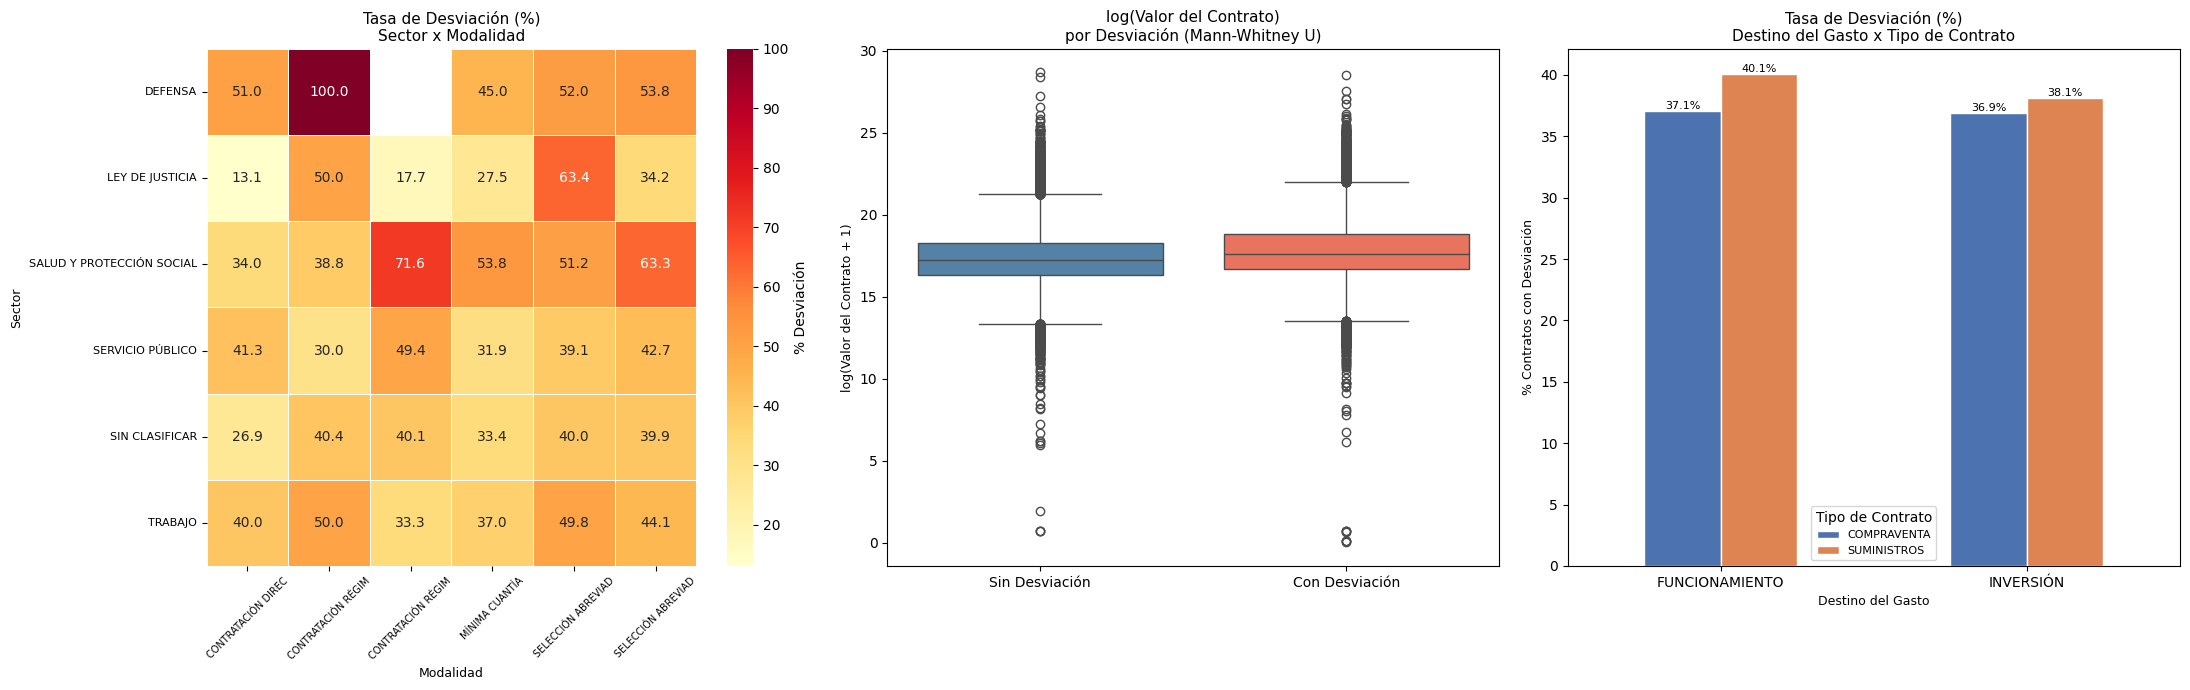

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Gráfica 1: Heatmap — Tasa de desviación Sector x Modalidad
top_sectores = df_clean['sector'].value_counts().nlargest(6).index
top_modalidades = df_clean['modalidad_de_contratacion'].value_counts().nlargest(6).index
df_hm = df_clean[
    df_clean['sector'].isin(top_sectores) &
    df_clean['modalidad_de_contratacion'].isin(top_modalidades)
]
pivot_hm = df_hm.pivot_table(
    values='desviacion_general', index='sector',
    columns='modalidad_de_contratacion', aggfunc='mean'
) * 100
pivot_hm.columns = [c[:18] for c in pivot_hm.columns]
sns.heatmap(pivot_hm, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '% Desviación'})
axes[0].set_title('Tasa de Desviación (%)\nSector x Modalidad', fontsize=11)
axes[0].set_xlabel('Modalidad', fontsize=9)
axes[0].set_ylabel('Sector', fontsize=9)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Gráfica 2: Boxplot — log(valor_del_contrato) por desviación
df_clean['log_valor'] = np.log1p(df_clean['valor_del_contrato'])
df_clean['etiqueta_desviacion'] = df_clean['desviacion_general'].map({0: 'Sin Desviación', 1: 'Con Desviación'})
sns.boxplot(
    data=df_clean, x='etiqueta_desviacion', y='log_valor',
    palette={'Sin Desviación': 'steelblue', 'Con Desviación': 'tomato'},
    order=['Sin Desviación', 'Con Desviación'], ax=axes[1]
)
axes[1].set_title('log(Valor del Contrato)\npor Desviación (Mann-Whitney U)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('log(Valor del Contrato + 1)', fontsize=9)

# Gráfica 3: Barplot — Tasa de desviación Destino x Tipo de Contrato
df_bar = (
    df_clean.groupby(['destino_gasto', 'tipo_de_contrato'])['desviacion_general']
    .mean() * 100
).reset_index()
df_bar.columns = ['destino_gasto', 'tipo_de_contrato', 'tasa']
df_bar = df_bar[df_bar['destino_gasto'].isin(['FUNCIONAMIENTO', 'INVERSIÓN'])]
pivot_bar = df_bar.pivot(index='destino_gasto', columns='tipo_de_contrato', values='tasa')
pivot_bar.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[2].set_title('Tasa de Desviación (%)\nDestino del Gasto x Tipo de Contrato', fontsize=11)
axes[2].set_xlabel('Destino del Gasto', fontsize=9)
axes[2].set_ylabel('% Contratos con Desviación', fontsize=9)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Tipo de Contrato', fontsize=8)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### Insights - Fase 3: Visualizaciones Multivariadas

**Heatmap Sector x Modalidad:**
Las celdas con tonos mas oscuros representan intersecciones donde confluyen sector de alto riesgo y modalidad poco competitiva: las ventanas de supervision mas criticas. Una fila uniformemente oscura indica riesgo alto independientemente de la modalidad usada, apuntando a problemas de gestion propios de la entidad.

**Boxplot log(valor) por desviacion:**
Complementa visualmente Mann-Whitney U. Si la mediana del grupo Con Desviacion esta sistematicamente por encima de Sin Desviacion, confirma que mayor valor financiero se asocia a mayor riesgo. La amplitud del IQR permite evaluar si la diferencia es consistente o esta dominada por contratos outliers.

**Barplot Destino x Tipo de Contrato:**
Segmenta la estrategia auditora segun la naturaleza del gasto. Si Suministros de Inversion exhibe la tasa mas alta, los entes de control deberian priorizar contratos de suministro en proyectos de inversion, que combinan complejidad de entrega con mayor monto comprometido.

### Fase 4 — Score de Riesgo Compuesto y Lista de Supervisión Prioritaria
El score suma las tres dimensiones de riesgo ya construidas (rango 0–3).
Los contratos con **score = 3** acumulan los tres tipos de desviación simultáneamente → máxima prioridad de supervisión.
La ordenación final por score (desc) y valor del contrato (desc) combina riesgo cualitativo y materialidad financiera.

=== Distribución del Score de Riesgo ===
  Score 0 (Sin riesgo): 83,360 contratos (61.6%)
  Score 1 (1 dimensión): 41,539 contratos (30.7%)
  Score 2 (2 dimensiones): 10,227 contratos (7.6%)
  Score 3 (Máximo riesgo): 174 contratos (0.1%)

=== Top 20 Contratos Candidatos a Supervisión Prioritaria ===
           id_contrato                                             nombre_entidad                            sector                    modalidad_de_contratacion  valor_del_contrato  score_riesgo  riesgo_plazo  riesgo_presupuesto  riesgo_liquidacion
0   CO1.PCCNTR.3641082                                     GOBERNACION DEL HUILA*                  SERVICIO PÚBLICO          SELECCIÓN ABREVIADA SUBASTA INVERSA        3.456317e+09             3             1                   1                   1
1   CO1.PCCNTR.8610011             HOSPITAL SAN RAFAEL DE EL ESPINAL TOLIMA E.S.E         SALUD Y PROTECCIÓN SOCIAL  CONTRATACIÓN RÉGIMEN ESPECIAL (CON OFERTAS)        2.933160e+09             3      

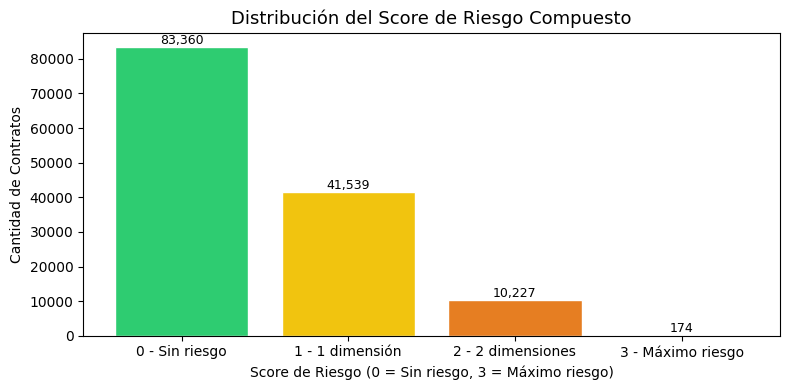

In [19]:
df_clean['score_riesgo'] = df_clean['riesgo_plazo'] + df_clean['riesgo_presupuesto'] + df_clean['riesgo_liquidacion']

print('=== Distribución del Score de Riesgo ===')
dist_score = df_clean['score_riesgo'].value_counts().sort_index()
total = dist_score.sum()
etiquetas_score = {0: 'Sin riesgo', 1: '1 dimensión', 2: '2 dimensiones', 3: 'Máximo riesgo'}
for score, n in dist_score.items():
    print(f'  Score {score} ({etiquetas_score.get(score, str(score))}): {n:,} contratos ({n/total*100:.1f}%)')

cols_output = ['id_contrato', 'nombre_entidad', 'sector', 'modalidad_de_contratacion',
               'valor_del_contrato', 'score_riesgo', 'riesgo_plazo', 'riesgo_presupuesto', 'riesgo_liquidacion']
top_supervision = (
    df_clean[cols_output]
    .sort_values(['score_riesgo', 'valor_del_contrato'], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)
print('\n=== Top 20 Contratos Candidatos a Supervisión Prioritaria ===')
print(top_supervision.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(dist_score.index, dist_score.values, color=colores[:len(dist_score)], edgecolor='white')
ax.set_title('Distribución del Score de Riesgo Compuesto', fontsize=13)
ax.set_xlabel('Score de Riesgo (0 = Sin riesgo, 3 = Máximo riesgo)', fontsize=10)
ax.set_ylabel('Cantidad de Contratos', fontsize=10)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 - Sin riesgo', '1 - 1 dimensión', '2 - 2 dimensiones', '3 - Máximo riesgo'])
for bar in bars:
    ax.annotate(f'{bar.get_height():,.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Insights - Fase 4: Score de Riesgo y Lista de Supervision Prioritaria

**Distribucion del score:**
La concentracion en score 0-1 refleja el desbalance natural en datos de riesgo publico. Los contratos con score 3 son pocos pero de maxima prioridad: acumulan adicion de plazo, presupuesto no ejecutado y cierre sin liquidar, la combinacion mas indicativa de gestion deficiente o irregularidades.

**Criterio de priorizacion:**
El Top-20 combina (1) severidad cualitativa: cuantos tipos de desviacion acumula, y (2) materialidad financiera: cuanto dinero publico esta en juego. Un contrato con score 2 y valor de $2,000M puede ser operativamente mas urgente que uno con score 3 y valor de $5M.

**Limitacion del score aditivo:**
El score trata las tres dimensiones con igual peso. Una extension natural seria ponderar diferencialmente (mayor peso a presupuesto no ejecutado por impacto fiscal directo) o construir un indice mediante regresion logistica o PCA.

**Conclusion general:**
Las pruebas Chi2 (H1a, H1b) y Mann-Whitney U (H2) confirman que modalidad, sector y valor tienen asociacion estadisticamente significativa con la ocurrencia de desviaciones. La supervision debe focalizar recursos en contratos de alto valor, adjudicados por modalidades poco competitivas, en sectores de riesgo identificados, especialmente cuando acumulen score >= 2.